## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
from joblib import dump
from paths import PROCESSED_DIR, MODEL_DIR, RESULT_DIR

## Load the data file

In [15]:
train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
test = pd.read_parquet(PROCESSED_DIR / 'test.parquet')
X_train = pd.read_parquet(PROCESSED_DIR / 'X_train.parquet')
y_train = pd.read_parquet(PROCESSED_DIR / 'y_train.parquet')['reordered']
X_test = pd.read_parquet(PROCESSED_DIR / 'X_test.parquet')
y_test = pd.read_parquet(PROCESSED_DIR / 'y_test.parquet')['reordered']

In [16]:
X_test

,up_total_bought,user_total_orders,user_avg_days_between,prod_total_purchases,prod_reorder_ratio
1224,1,7,22.214286,29,0.413793
1225,1,7,22.214286,6,0.333333
1226,1,7,22.214286,82,0.682927
1227,1,7,22.214286,2,0.000000
1228,1,7,22.214286,63,0.460317
...,...,...,...,...,...
126036,1,21,17.255605,66,0.621212
126037,1,21,17.255605,121,0.504132
126038,1,21,17.255605,3,0.000000
126039,7,21,17.255605,14,0.785714


## Train the Random Forest model

In [3]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

In [4]:
model.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Make predictions on the test set and calculate evaluation metrics

In [5]:
test_pred_prob = model.predict_proba(X_test)[:, 1]
test_pred_05 = (test_pred_prob >= 0.5).astype(int)

print('AUC:       ', round(roc_auc_score(y_test, test_pred_prob), 4))
print('PR-AUC:    ', round(average_precision_score(y_test, test_pred_prob), 4))
print('F1@0.50:   ', round(f1_score(y_test, test_pred_05, zero_division=0), 4))
print('Precision: ', round(precision_score(y_test, test_pred_05, zero_division=0), 4))
print('Recall:    ', round(recall_score(y_test, test_pred_05, zero_division=0), 4))

AUC:        0.7273
PR-AUC:     0.1658
F1@0.50:    0.2334
Precision:  0.2317
Recall:     0.2352


## Search for the optimal classification threshold

In [6]:
threshold_results = []

for th in np.arange(0.10, 0.91, 0.05):
    pred = (test_pred_prob >= th).astype(int)
    threshold_results.append({
        'threshold': round(float(th), 2),
        'f1': f1_score(y_test, pred, zero_division=0),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results).sort_values('f1', ascending=False)
threshold_df.head(10)

,threshold,f1,precision,recall
7,0.45,0.235222,0.203586,0.278499
6,0.40,0.233753,0.181492,0.328283
8,0.50,0.233441,0.231699,0.235209
5,0.35,0.228388,0.162170,0.386003
9,0.55,0.221671,0.259690,0.193362
4,0.30,0.221493,0.145616,0.462482
3,0.25,0.207013,0.128609,0.530303
2,0.20,0.192760,0.114104,0.620491
10,0.60,0.186178,0.267206,0.142857
1,0.15,0.171909,0.097836,0.707792


## Select the threshold with the best F1-score from the results above

In [7]:
best_threshold = float(threshold_df.iloc[0]['threshold'])
best_f1 = float(threshold_df.iloc[0]['f1'])

best_pred = (test_pred_prob >= best_threshold).astype(int)

print('Best threshold:', best_threshold)
print('Best F1:       ', round(best_f1, 4))
print('Precision:     ', round(precision_score(y_test, best_pred, zero_division=0), 4))
print('Recall:        ', round(recall_score(y_test, best_pred, zero_division=0), 4))

Best threshold: 0.45
Best F1:        0.2352
Precision:      0.2036
Recall:         0.2785


## Calculate feature importance

In [8]:
X_train.columns

Index(['up_total_bought', 'user_total_orders', 'user_avg_days_between',
       'prod_total_purchases', 'prod_reorder_ratio'],
      dtype='object')

In [9]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df

,feature,importance
2,user_avg_days_between,0.243727
4,prod_reorder_ratio,0.214003
1,user_total_orders,0.187349
3,prod_total_purchases,0.180302
0,up_total_bought,0.174620


## Plot the top 15 most important features as a horizontal bar chart

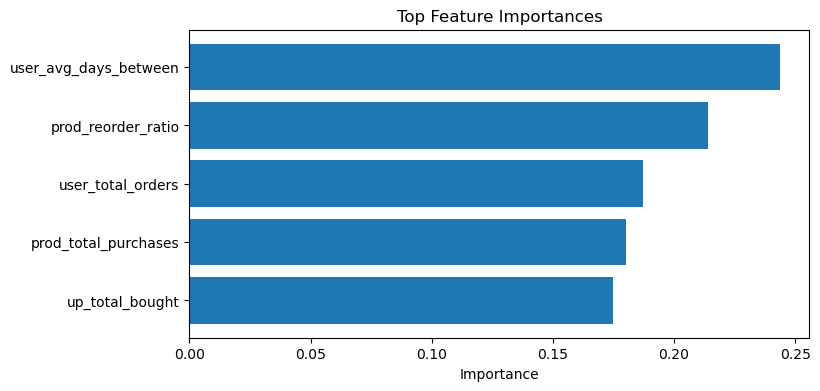

In [10]:
plt.figure(figsize=(8, 4))
top_imp = importance_df.head(15).sort_values('importance')
plt.barh(top_imp['feature'], top_imp['importance'])
plt.title('Top Feature Importances')
plt.xlabel('Importance')
plt.show()

## Combine ground truth and predictions into a table

In [11]:
test_result = test[['user_id', 'product_id', 'reordered']].copy()
test_result['pred_prob'] = test_pred_prob
test_result['pred_label_0.50'] = test_pred_05
test_result['pred_label_best'] = best_pred

test_result.head()

,user_id,product_id,reordered,pred_prob,pred_label_0.50,pred_label_best
1224,2430,546,0,0.114019,0,0
1225,2430,714,0,0.416178,0,0
1226,2430,2120,0,0.133374,0,0
1227,2430,6592,0,0.007473,0,0
1228,2430,7644,0,0.183817,0,0


## Save the test predictions and the trained Random Forest model

In [12]:
MODEL_PATH = MODEL_DIR / 'random_forest_model.joblib'
RESULT_PATH = RESULT_DIR / 'test_predictions_random_forest.csv'
test_result.to_csv(RESULT_PATH, index=False)
dump(model, MODEL_PATH)
print('Saved:', RESULT_PATH.resolve())
print('Saved:', MODEL_PATH.resolve())

Saved: C:\CS\Project\internships_prep\Group_8_Final_Project\Final_Project_Code_Random_Forest\resources\data\results\test_predictions_random_forest.csv
Saved: C:\CS\Project\internships_prep\Group_8_Final_Project\Final_Project_Code_Random_Forest\resources\models\random_forest_model.joblib


## Predict for a single user-product pair

In [13]:
def predict_reorder(user_id, product_id, feature_table, trained_model, feature_columns, threshold):
    row = feature_table[(feature_table['user_id'] == user_id) & (feature_table['product_id'] == product_id)]
    if row.empty:
        return f'No existing features found for user_id={user_id}, product_id={product_id}'
    x = row[feature_columns]
    prob = trained_model.predict_proba(x)[:, 1][0]
    label = int(prob >= threshold)
    return {
        'user_id': int(user_id),
        'product_id': int(product_id),
        'pred_prob': float(prob),
        'pred_label': label,
        'threshold': float(threshold)
    }